# Import Libraries

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

D:\Anaconda\envs\AI\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


# Training Dataset Pre-Processing

In [2]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 8

## Load & Preprocessing of Training Data

In [3]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    'Fruit/train',
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 5600 files belonging to 8 classes.


## Load & Preprocessing of Validation Data

In [4]:
val_data = tf.keras.preprocessing.image_dataset_from_directory(
    'Fruit/val',
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1600 files belonging to 8 classes.


## Load & Preprocessing of Test Data

In [5]:
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    'Fruit/test',
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 800 files belonging to 8 classes.


## Summary of Dataset

In [6]:
class_names = train_data.class_names

# --- Convert train to numpy ---
X_train, y_train = [], []
for images, labels in train_data:
    X_train.append(images.numpy())
    y_train.append(labels.numpy())
X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)

# --- Convert val to numpy ---
X_test, y_test = [], []
for images, labels in val_data:
    X_test.append(images.numpy())
    y_test.append(labels.numpy())
X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

# --- Inspect ---
print(f'Training images shape : {X_train.shape}')
print(f'Training labels shape : {y_train.shape}')
print(f'Validate images shape     : {X_test.shape}')
print(f'Validate labels shape     : {y_test.shape}')
print(f'Pixel value range     : {X_train.min()} to {X_train.max()}')
print(f'Number of classes     : {len(class_names)}')
print("Classes:", class_names)

Training images shape : (5600, 128, 128, 3)
Training labels shape : (5600, 8)
Validate images shape     : (1600, 128, 128, 3)
Validate labels shape     : (1600, 8)
Pixel value range     : 0.0 to 255.0
Number of classes     : 8
Classes: ['Apple', 'Avocado', 'Banana', 'Grapes', 'Mangosteen', 'Orange', 'Pineapple', 'Pomegranate']


## Fruit Dataset Sample Training Images

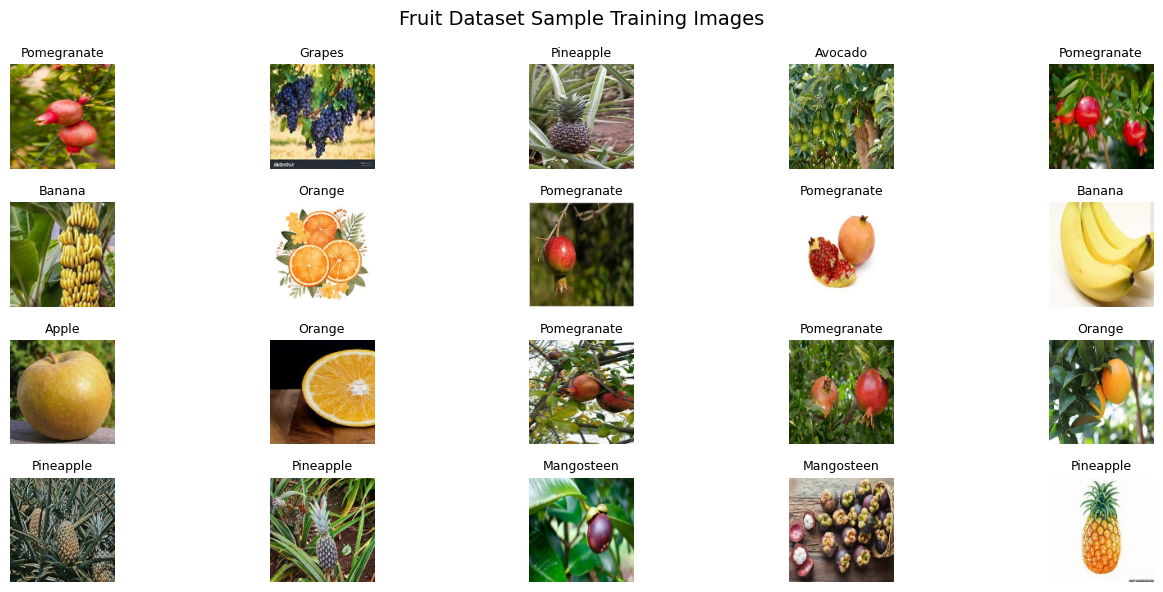

In [7]:
plt.figure(figsize=(14, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train[i].astype("uint8"))
    plt.title(class_names[np.argmax(y_train[i])], fontsize=9)
    plt.axis('off')

plt.suptitle('Fruit Dataset Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

## Dataset Class Distribution

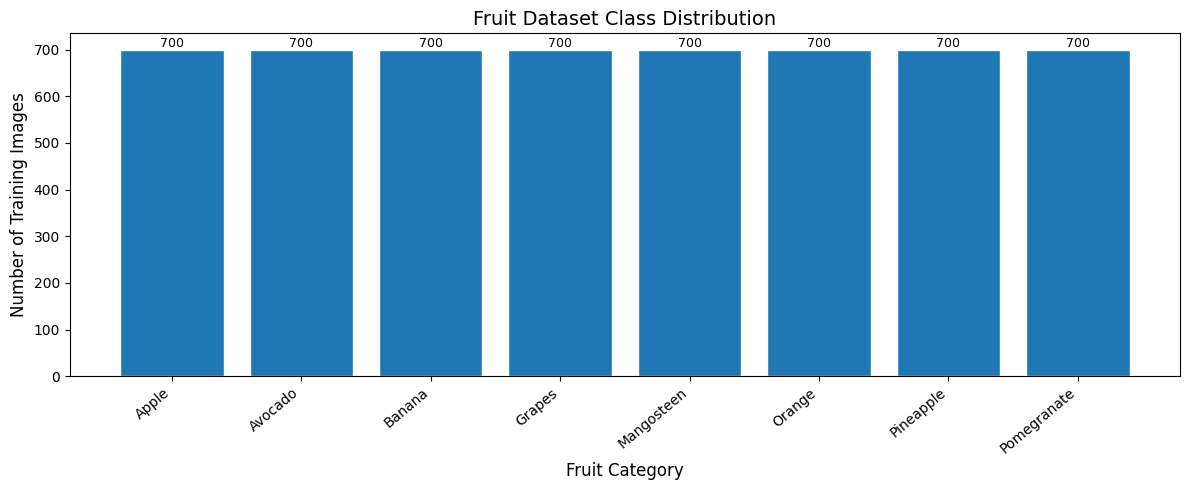


Images per class:
  Apple          : 700
  Avocado        : 700
  Banana         : 700
  Grapes         : 700
  Mangosteen     : 700
  Orange         : 700
  Pineapple      : 700
  Pomegranate    : 700


In [8]:
# Convert one-hot labels to class index
y_train_labels = np.argmax(y_train, axis=1)

unique, counts = np.unique(y_train_labels, return_counts=True)

plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, counts, edgecolor='white')

plt.xlabel('Fruit Category', fontsize=12)
plt.ylabel('Number of Training Images', fontsize=12)
plt.title('Fruit Dataset Class Distribution', fontsize=14)
plt.xticks(rotation=40, ha='right')

# Add count labels
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             str(count),
             ha='center',
             fontsize=9)

plt.tight_layout()
plt.show()

print('\nImages per class:')
for name, count in zip(class_names, counts):
    print(f'  {name:<14} : {count:,}')

## Normalize pixel values (0-255 -> 0-1)

In [10]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))
test_data = test_data.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.cache().shuffle(1000).prefetch(AUTOTUNE)
val_data = val_data.cache().prefetch(AUTOTUNE)
test_data = test_data.cache().prefetch(AUTOTUNE)

# CCN Model

In [12]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,672 (12.61 MB)

 Trainable params: 3,305,672 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# Compile the Model

In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the Model

In [15]:
EPOCHS = 10

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

Epoch 1/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 47s 63ms/step - accuracy: 0.4875 - loss: 1.4135 - val_accuracy: 0.6075 - val_loss: 1.1190
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.6637 - loss: 0.9586 - val_accuracy: 0.6187 - val_loss: 1.1056
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.7580 - loss: 0.7079 - val_accuracy: 0.7175 - val_loss: 0.7988
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.8188 - loss: 0.5139 - val_accuracy: 0.7556 - val_loss: 0.7550
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 50s 72ms/step - accuracy: 0.8830 - loss: 0.3508 - val_accuracy: 0.7381 - val_loss: 0.8628
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.9293 - loss: 0.2084 - val_accuracy: 0.7594 - val_loss: 1.0027
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.9486 - loss: 0.1582 - val_accuracy: 0.7544 - val_loss: 1.1394
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.9641 - loss: 0.1187 - 

# Accuracy vs Val_Accuracy

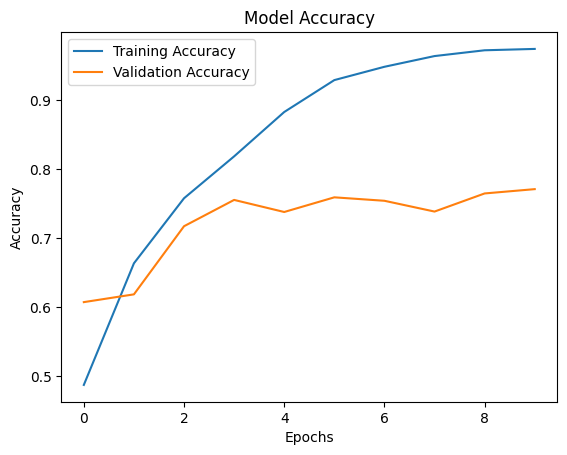

In [17]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.show()

# Loss vs Val_Loss

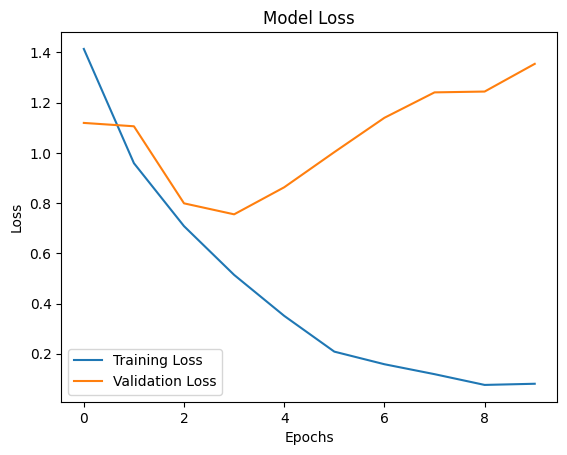

In [18]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.show()

## Model Evaluation

In [20]:
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Accuracy:", test_accuracy*100)

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7600 - loss: 1.3917
Test Accuracy: 75.99999904632568


## Confusion Matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━

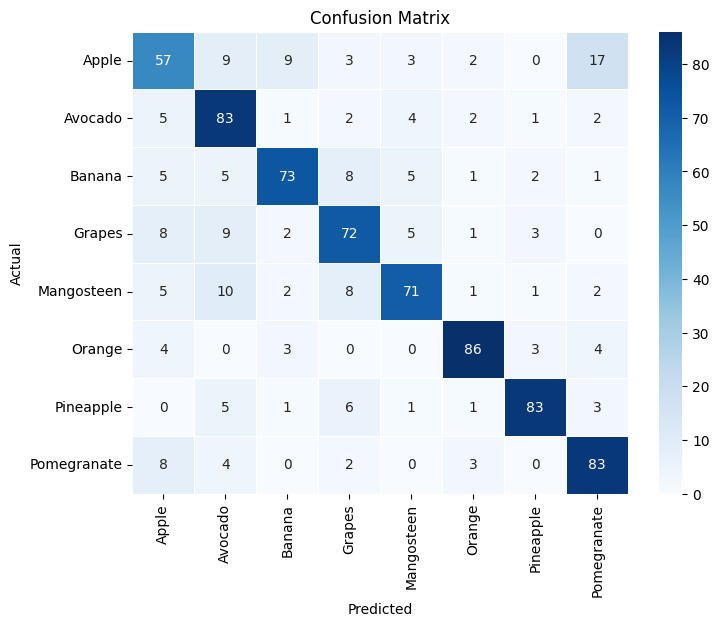

In [23]:
y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [24]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       Apple       0.62      0.57      0.59       100
     Avocado       0.66      0.83      0.74       100
      Banana       0.80      0.73      0.76       100
      Grapes       0.71      0.72      0.72       100
  Mangosteen       0.80      0.71      0.75       100
      Orange       0.89      0.86      0.87       100
   Pineapple       0.89      0.83      0.86       100
 Pomegranate       0.74      0.83      0.78       100

    accuracy                           0.76       800
   macro avg       0.76      0.76      0.76       800
weighted avg       0.76      0.76      0.76       800



In [26]:
print('\nMost Common Misclassifications (> 10 occurrences):')
print('-' * 60)

num_classes = len(class_names)

for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 10:   # threshold adjustable
            print(f'  {class_names[i]:<15} misclassified as '
                  f'{class_names[j]:<15} : {cm[i,j]} times')


Most Common Misclassifications (> 10 occurrences):
------------------------------------------------------------
  Apple           misclassified as Pomegranate     : 17 times


# Save the Model

In [27]:
model.save("Fruits_Classifier_Model_01.h5")

# Save Training History

In [29]:
import json
with open("Trained_History_Model_1.json",'w') as f:
    json.dump(history.history,f)